"Sales & Demand Forecasting using Machine Learning"

Problem Statement

This project aims to predict future sales based on historical business data using machine learning techniques.
By analyzing past sales trends and time-based features, the model helps businesses make better decisions
regarding inventory management, demand planning, and resource allocation.

In [ ]:
#step 01:I imported required libraries like pandas, numpy, matplotlib, and sklearn.
# These are used for data handling, visualization, and machine learning.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [ ]:
#step 02: Load the dataset into a dataframe
data = pd.read_csv("Sample - Superstore.csv", encoding='latin1')
print(data.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [ ]:
import os
print(os.listdir())

['Sample - Superstore.csv', 'TASK_01.ipynb']


In [ ]:
#step 03: Load the dataset from CSV file and display the first few rows
import pandas as pd

data = pd.read_csv("Sample - Superstore.csv", encoding='latin1')
print(data.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [ ]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
#step 04: Convert date column and extract year, month, and day for time-based analysis

data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Year'] = data['Order Date'].dt.year
data['Month'] = data['Order Date'].dt.month
data['Day'] = data['Order Date'].dt.day

print(data[['Order Date','Year','Month','Day']].head())

  Order Date  Year  Month  Day
0 2016-11-08  2016     11    8
1 2016-11-08  2016     11    8
2 2016-06-12  2016      6   12
3 2015-10-11  2015     10   11
4 2015-10-11  2015     10   11


In [ ]:
#step 05: Convert date column, extract year & month, and calculate total monthly sales

data['Order Date'] = pd.to_datetime(data['Order Date'])

data['Year'] = data['Order Date'].dt.year
data['Month'] = data['Order Date'].dt.month

monthly_sales = data.groupby(['Year','Month'])['Sales'].sum().reset_index()

print(monthly_sales.head())

   Year  Month      Sales
0  2014      1  14236.895
1  2014      2   4519.892
2  2014      3  55691.009
3  2014      4  28295.345
4  2014      5  23648.287


In [ ]:
X = monthly_sales[['Month']]
y = monthly_sales['Sales']

In [ ]:
#step 06: Split the dataset into training and testing sets for model evaluation
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# step 07:Generate predictions on test data and display first few predicted values

predictions = model.predict(X_test)
print(predictions[:5])

[34478.72251213 39839.20481328 29118.24021098 55920.65171673
 18397.27560868]


In [ ]:
#step 08: Evaluate model performance using Mean Absolute Error

from sklearn.metrics import mean_absolute_error

error = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error:", error)

Mean Absolute Error: 7830.831309655067


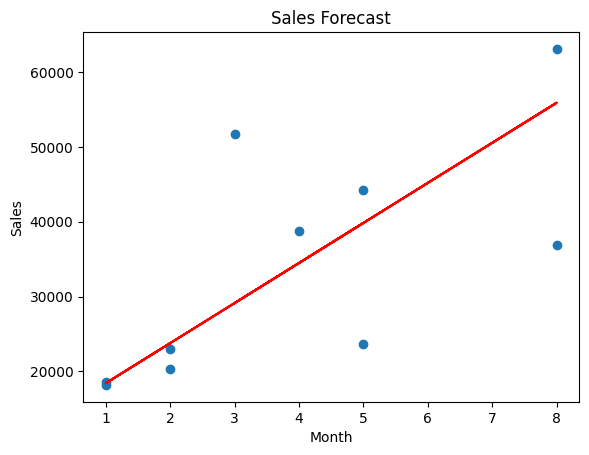

In [ ]:
# step 09:Visualize actual vs predicted sales using scatter plot and regression line
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test)
plt.plot(X_test, predictions, color='red')
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Sales Forecast")
plt.show()

In [ ]:
#step 10: Predict future sales for a given month using the trained model

future_month = pd.DataFrame({'Month':[12]})
future_sales = model.predict(future_month)

print("Predicted Sales:", future_sales)

Predicted Sales: [77362.58092133]
